# 5. 指标性质与不确定性

## 学习目标
计算 ABL/HOT/CTQ/DHI/MAB，并观察三套权重与标签误差的影响。

**数据来源：** 原有方法实验使用 `aiv/data.py` 的确定性合成样本；本页后半部读取 `results/final-analysis/` 的真实聚合观察或条件分析。两类结果分别标明范围。

## 运行准备
在项目环境中从干净内核运行全部单元。默认不读取 .env、不调用 API。

In [1]:
from pathlib import Path
import sys, json

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "aiv").is_dir())
sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update(
    {
        "figure.figsize": (8, 4),
        "font.size": 11,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)
from aiv.data import synthetic_records

records = synthetic_records(seed=26)
LIVE_API = False  # Explicit opt-in only. Default cells never spend credits.
from aiv.notebook_materials import configure_style, save_figure
configure_style()

## 三套固定权重

,student,balanced,higher_order,process
0,S001,68.21,62.09,59.30
1,S002,64.71,59.84,56.05
2,S003,66.14,57.27,60.66
3,S004,65.93,61.30,59.23
4,S005,73.50,70.38,65.13
5,S006,66.36,61.48,59.34
6,S007,71.43,69.68,65.11
7,S008,61.93,54.18,55.61
8,S009,54.79,40.54,49.32
9,S010,65.79,56.54,58.82


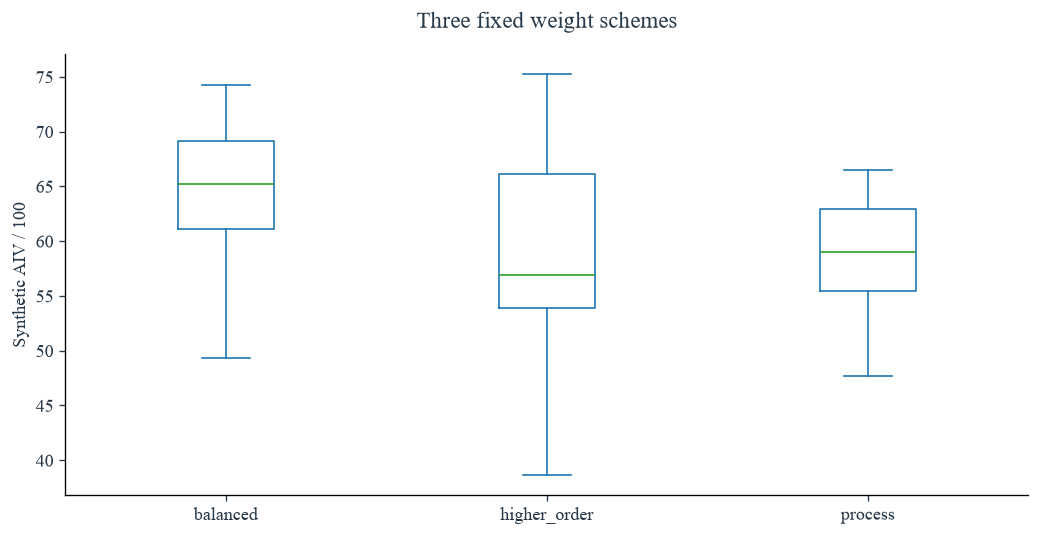

In [2]:
from aiv.analysis import student_scores, weight_sensitivity
from aiv.metrics import metrics, composite, dhi, IDEAL, transition_quality

scores = student_scores(records)
display(scores[["student", "balanced", "higher_order", "process"]].head(10).round(2))
scores[["balanced", "higher_order", "process"]].plot.box()
plt.ylabel("Synthetic AIV / 100")
plt.title("Three fixed weight schemes")
plt.tight_layout()
save_figure(plt.gcf(), 'synthetic-05-01', '合成实验：三套固定权重', kind='synthetic', sources=['aiv/data.py', 'aiv/analysis.py', 'aiv/metrics.py', 'results/synthetic/label-dependence.csv'], notebook='05_指标性质与不确定性.ipynb')
plt.show()

权重代表预先指定的教育侧重点；理想分布是设计假设，没有被当作实证最优值。

## 权重敏感性

,student,score_low,score_high,rank_low,rank_high
0,S001,67.35,69.05,8.0,8.0
1,S002,63.77,65.66,13.0,13.0
2,S003,65.31,67.00,9.0,11.0
3,S004,65.02,66.83,10.0,12.0
4,S005,72.67,74.30,2.0,2.0
5,S006,65.47,67.23,9.0,10.0
6,S007,70.61,72.27,4.0,4.0
7,S008,60.98,62.91,16.0,17.0


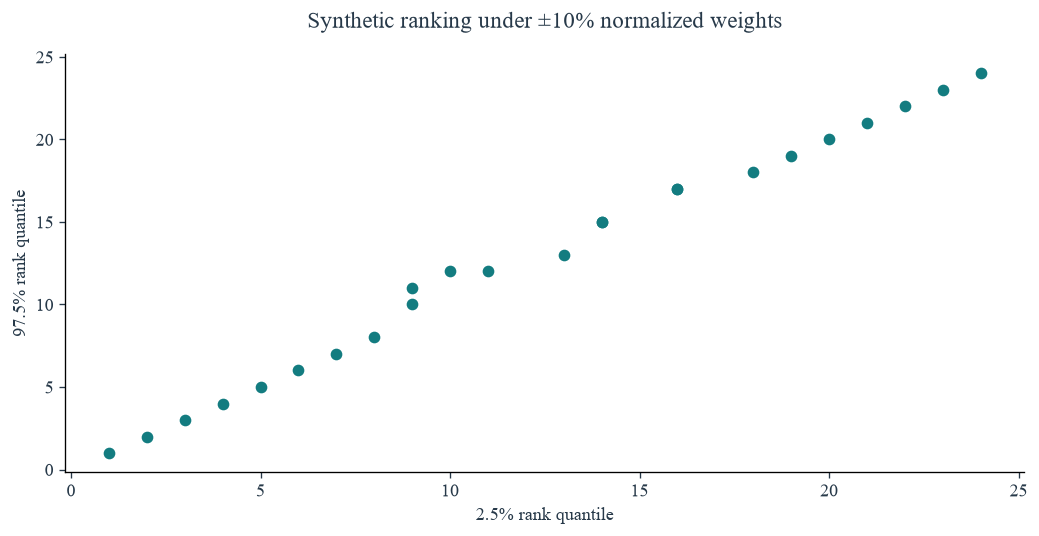

In [3]:
sensitivity = weight_sensitivity(scores)
display(sensitivity.head(8).round(2))
plt.scatter(sensitivity.rank_low, sensitivity.rank_high, color="#137c80")
plt.xlabel("2.5% rank quantile")
plt.ylabel("97.5% rank quantile")
plt.title("Synthetic ranking under ±10% normalized weights")
plt.tight_layout()
save_figure(plt.gcf(), 'synthetic-05-02', '合成实验：权重敏感性', kind='synthetic', sources=['aiv/data.py', 'aiv/analysis.py', 'aiv/metrics.py', 'results/synthetic/label-dependence.csv'], notebook='05_指标性质与不确定性.ipynb')
plt.show()

排名分位范围由固定扰动机制得到，不是经覆盖率校验的统计置信区间。标签误差的传播还依赖联合错误结构。

## 标签共同误差敏感性
保持每条标签边际概率不变，改变共享随机数的混合比例。ρ 是依赖混合参数，不是实际 Pearson 相关系数。区间仍是指定模型下的分位范围。

,dependence_mixture,low,median,high,width,source
0,0.0,59.489,68.214,73.714,14.225,synthetic_assumed_probabilities
1,0.5,42.000,68.214,74.214,32.214,synthetic_assumed_probabilities
2,1.0,32.000,68.214,75.714,43.714,synthetic_assumed_probabilities


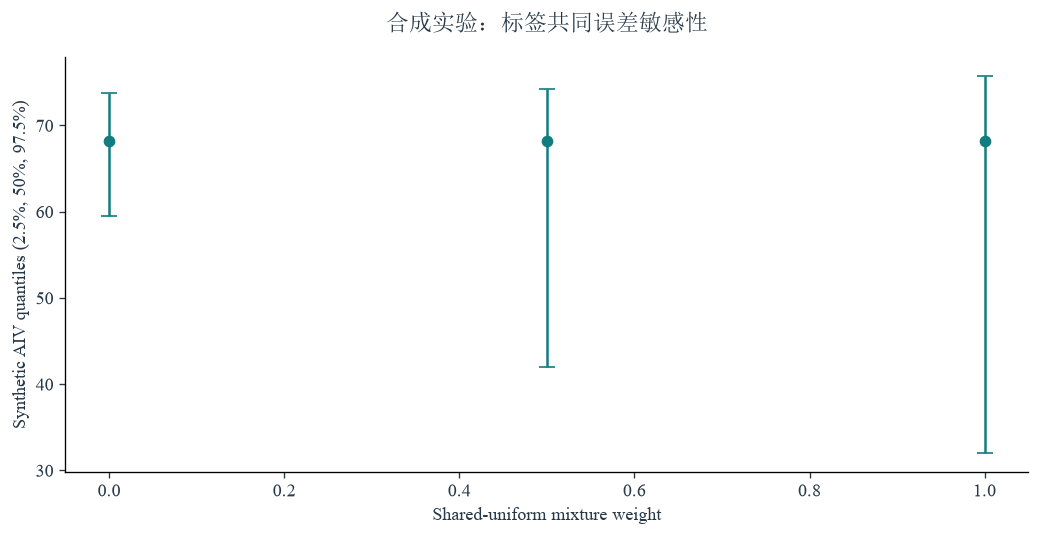

In [4]:
dependence = pd.read_csv(ROOT / "results/synthetic/label-dependence.csv")
display(dependence.round(3))
plt.errorbar(
    dependence.dependence_mixture,
    dependence["median"],
    yerr=[
        dependence["median"] - dependence.low,
        dependence.high - dependence["median"],
    ],
    fmt="o",
    capsize=5,
    color="#137c80",
)
plt.xlabel("Shared-uniform mixture weight")
plt.ylabel("Synthetic AIV quantiles (2.5%, 50%, 97.5%)")
plt.tight_layout()
save_figure(plt.gcf(), 'synthetic-05-03', '合成实验：标签共同误差敏感性', kind='synthetic', sources=['aiv/data.py', 'aiv/analysis.py', 'aiv/metrics.py', 'results/synthetic/label-dependence.csv'], notebook='05_指标性质与不确定性.ipynb')
plt.show()

## 计算检查

In [5]:
assert dhi(IDEAL) == 1
assert transition_quality([2, 3], [None, None]) is None
assert scores.balanced.between(0, 100).all()

## 继续研究
阅读 `docs/指标定义与性质.md`；测试 CTQ 对复制/分段的敏感性与 MAB 的工具堆叠漏洞。

## 条件分析：把未知标签保留在学期分母中
暂时接受已给出的候选标签正确，将其余回合的层级限制在 L1–L6，可得到 ABL 与 HOT 的可行范围。
范围描述指定假设下的极值，未引入错标率或抽样误差模型。
来源：`unknown-label-bounds.csv`、`term-contrast-bounds.csv` 与 `summary.json`，均位于 `results/final-analysis/`。

In [6]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from aiv.notebook_materials import configure_style, save_figure
configure_style()
FINAL_DIR = ROOT / "results" / "final-analysis"
_final_summary_path = FINAL_DIR / "summary.json"
final_summary = json.loads(_final_summary_path.read_text(encoding="utf-8")) if _final_summary_path.is_file() else None

def final_csv(name):
    return pd.read_csv(FINAL_DIR / name) if final_summary is not None else pd.DataFrame()

if final_summary is None:
    display(Markdown("本目录未附真实聚合分析；以下真实结果保持空白，前面的合成实验仍可复算。"))
else:
    display(pd.DataFrame([{
        "分析输入": "results/final-analysis/summary.json",
        "冻结修订": final_summary["source"]["revision"],
        "快照清单 SHA-256": final_summary["source"]["manifest_sha256"],
        "真实回合": final_summary["denominators"]["real_turns"],
        "学生—学期": final_summary["denominators"]["student_terms"],
    }]))

,分析输入,冻结修订,快照清单 SHA-256,真实回合,学生—学期
0,results/final-analysis/summary.json,t3,7e885ceecf12a180349369ed9ddfc962ad71f1ea270f68...,3515,401


,total_turns,candidate_turns,unknown_turns,candidate_abl_raw,abl_raw_lower,abl_raw_upper,candidate_hot,hot_lower,hot_upper
term,,,,,,,,,
25f,2509,661,1848,2.554,1.409,5.092,0.195,0.051,0.788
26s,1006,349,657,1.734,1.254,4.520,0.080,0.028,0.681


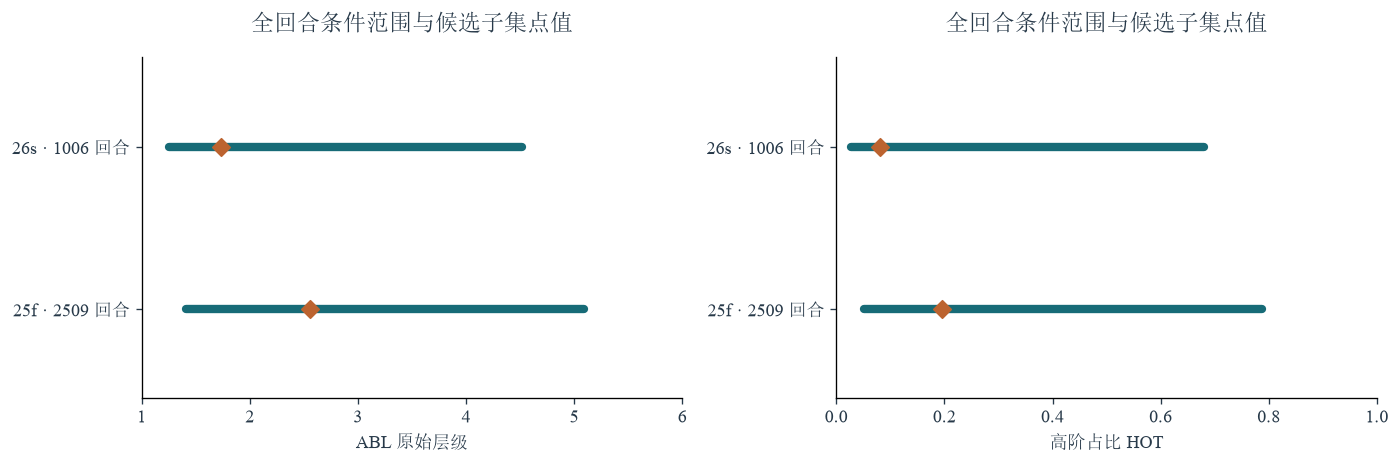

,kind,contrast,dimension,metric,candidate_only_difference,all_turn_lower,all_turn_upper
0,conditional,spring_minus_autumn,task,abl_raw,-0.8202,-3.8376,3.1106
1,conditional,spring_minus_autumn,task,hot,-0.1149,-0.7601,0.6295


In [7]:
if final_summary is not None:
    unknown = final_csv("unknown-label-bounds.csv")
    task_bounds = unknown.loc[unknown.dimension.eq("task") & unknown.term.isin(["25f", "26s"])].set_index("term").loc[["25f", "26s"]]
    display(task_bounds[["total_turns", "candidate_turns", "unknown_turns", "candidate_abl_raw", "abl_raw_lower", "abl_raw_upper", "candidate_hot", "hot_lower", "hot_upper"]].round(3))
    fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.0))
    for ax, key, label, limits in [(axes[0], "abl_raw", "ABL 原始层级", (1, 6)), (axes[1], "hot", "高阶占比 HOT", (0, 1))]:
        for y, (term, row) in enumerate(task_bounds.iterrows()):
            ax.plot([row[key+"_lower"], row[key+"_upper"]], [y, y], color="#176B77", linewidth=5, solid_capstyle="round")
            ax.scatter(row["candidate_"+key], y, color="#BC632F", marker="D", s=55, zorder=3)
        ax.set_yticks([0, 1], [f"25f · {int(task_bounds.loc['25f', 'total_turns'])} 回合", f"26s · {int(task_bounds.loc['26s', 'total_turns'])} 回合"])
        ax.set(xlim=limits, ylim=(-.55, 1.55), xlabel=label, title="全回合条件范围与候选子集点值")
    fig.tight_layout()
    save_figure(fig, "final-unknown-label-bounds", "线段为未知标签任取L1–L6的条件范围，菱形为候选子集点值；已判定标签暂视为正确。", kind="conditional", sources=["results/final-analysis/unknown-label-bounds.csv", "results/final-analysis/summary.json"], notebook="05_指标性质与不确定性.ipynb")
    plt.show()
    contrasts = final_csv("term-contrast-bounds.csv")
    display(contrasts.loc[contrasts.dimension.eq("task")].round(4))

学期差取“春季减秋季”。仅使用任务候选时 ABL 与 HOT 的差为负；纳入全部未知标签后，两项差的条件范围均跨过 0。
这些范围不支持确定学期差方向，也不代表学生能力差或 AI 处理效应。

## 条件分析：缺失指标、改标预算与权重
范围计算覆盖 356 个有任务候选的学生—学期单位：全部缺少已验证 CTQ 边，其中 99 个还缺工具身份。
每组重新使用同一标签向量计算相关指标，再对缺失指标和权重进行外包界分析。

,scheme,label_error_fraction,candidate_students,label_budget_min,label_budget_max,effective_changed_fraction_median,effective_changed_fraction_max,width_median,stably_distinguishable_pairs,within_term_pairs
1,balanced,0.00,356,0,0,0.0,0.0,24.331,3651,37747
3,higher_order,0.00,356,0,0,0.0,0.0,24.136,9638,37747
5,process,0.00,356,0,0,0.0,0.0,45.183,0,37747
7,balanced,0.05,356,1,2,0.5,1.0,68.107,0,37747
9,higher_order,0.05,356,1,2,0.5,1.0,68.185,1,37747
11,process,0.05,356,1,2,0.5,1.0,77.273,0,37747
13,balanced,0.10,356,1,3,0.5,1.0,68.107,0,37747
15,higher_order,0.10,356,1,3,0.5,1.0,68.185,1,37747
17,process,0.10,356,1,3,0.5,1.0,77.273,0,37747
19,balanced,0.20,356,1,6,0.5,1.0,69.619,0,37747


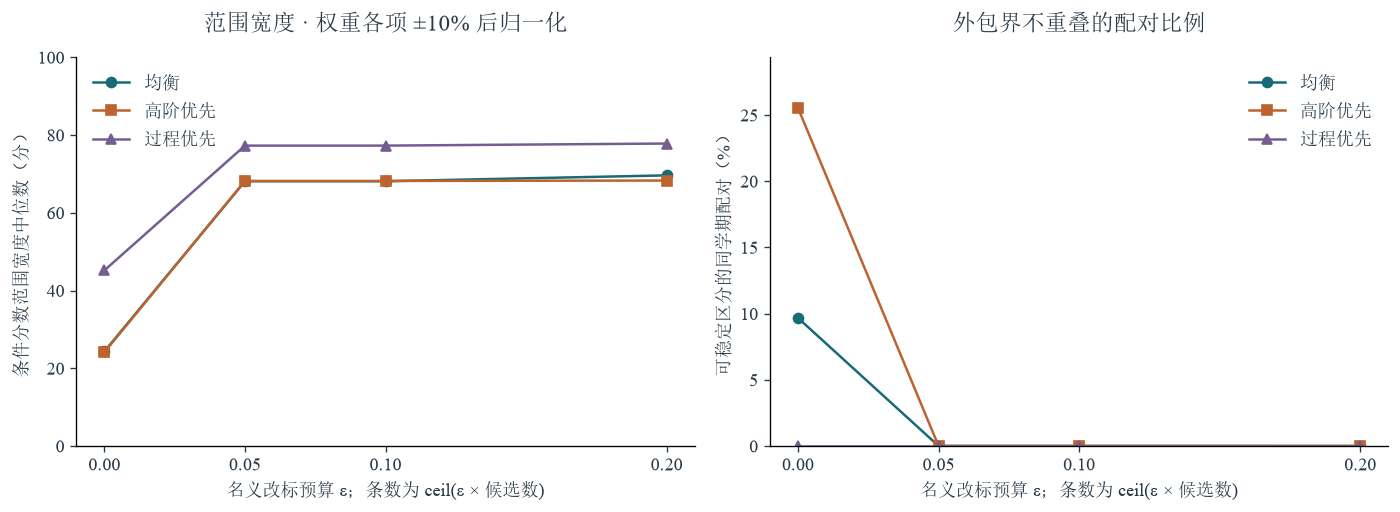

ε=0.05 时向上取整后的实际可改标比例：中位数 **50%**，最大 **100%**。候选数较少时，名义5%可对应一条乃至全部候选；应连同实际预算阅读曲线。

In [8]:
if final_summary is not None:
    ranges = final_csv("score-range-sensitivity.csv")
    selected_ranges = ranges.loc[ranges.term.eq("all") & np.isclose(ranges.weight_relative_change, .1)]
    display(selected_ranges[["scheme", "label_error_fraction", "candidate_students", "label_budget_min", "label_budget_max", "effective_changed_fraction_median", "effective_changed_fraction_max", "width_median", "stably_distinguishable_pairs", "within_term_pairs"]].round(3))
    fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.4))
    scheme_names = {"balanced": "均衡", "higher_order": "高阶优先", "process": "过程优先"}
    for (scheme, group), color, marker in zip(selected_ranges.groupby("scheme", sort=False), ["#176B77", "#BC632F", "#765D91"], ["o", "s", "^"]):
        group = group.sort_values("label_error_fraction")
        label = scheme_names.get(scheme, scheme)
        axes[0].plot(group.label_error_fraction, group.width_median, marker=marker, color=color, label=label)
        axes[1].plot(group.label_error_fraction, 100*group.stable_pair_fraction, marker=marker, color=color, label=label)
    axes[0].set(ylabel="条件分数范围宽度中位数（分）", ylim=(0, 100), title="范围宽度 · 权重各项 ±10% 后归一化")
    axes[1].set(ylabel="可稳定区分的同学期配对（%）", ylim=(0, max(1, selected_ranges.stable_pair_fraction.max()*115)), title="外包界不重叠的配对比例")
    for ax in axes:
        ax.set_xlabel("名义改标预算 ε；条数为 ceil(ε × 候选数)")
        ax.set_xticks(sorted(selected_ranges.label_error_fraction.unique()))
        ax.legend(frameon=False)
    fig.tight_layout()
    save_figure(fig, "final-score-range-sensitivity", "356个有任务候选的学生—学期单位；按ceil(εn)改标，缺失CTQ及工具情景保留；稳定配对仅在同学期内比较。", kind="conditional", sources=["results/final-analysis/score-range-sensitivity.csv", "results/final-analysis/summary.json"], notebook="05_指标性质与不确定性.ipynb")
    plt.show()
    small_budget = selected_ranges.loc[np.isclose(selected_ranges.label_error_fraction, .05)].iloc[0]
    display(Markdown(f"ε=0.05 时向上取整后的实际可改标比例：中位数 **{small_budget.effective_changed_fraction_median:.0%}**，最大 **{small_budget.effective_changed_fraction_max:.0%}**。候选数较少时，名义5%可对应一条乃至全部候选；应连同实际预算阅读曲线。"))

外包界不重叠是给定方案和假设下可区分的充分条件。重叠表示该检验不能稳定区分，不能推断学生能力相等。
即使不改标签，缺失的 CTQ 和工具信息也使范围保持一定宽度；这些范围不是 95% 置信区间。